## <center>PRJ-3. EDA+Feature Engineering. Соревнование на Kaggle</center>

### Постановка задачи

Представьте, что вы работаете дата-сайентистом в компании Booking. Одна из проблем компании — это нечестные отели, которые накручивают себе рейтинг. 

### Цель проекта 

Построить модель на основе алгоритмов машинного обучения, которая предсказывает рейтинг отеля.

### Задачи проекта

1. ознакомиться с входными данными (датасет с информацией об отелях);
2. изучить пример машинного обучения (scikit-learn класс RandomForestRegressor);
3. выполнить подготовку данных, которые будут использованы для обучения модели;
4. проверить эффективность предлагаемой модели, используя метрику MAPE
5. принять участие в соревновании на площадке в kaggle.com.


Первоначальная версия датасета содержит 17 полей со следующей информацией:

- hotel_address — адрес отеля;
- review_date — дата, когда рецензент разместил соответствующий отзыв;
- average_score — средний балл отеля, рассчитанный на основе последнего комментария за последний год;
- hotel_name — название отеля;
- reviewer_nationality — страна рецензента;
- negative_review — отрицательный отзыв, который рецензент дал отелю;
- review_total_negative_word_counts — общее количество слов в отрицательном отзыв;
- positive_review — положительный отзыв, который рецензент дал отелю;
- review_total_positive_word_counts — общее количество слов в положительном отзыве;
- reviewer_score — оценка, которую рецензент поставил отелю на основе своего опыта;
- total_number_of_reviews_reviewer_has_given — количество отзывов, которые рецензенты дали в прошлом;
- total_number_of_reviews — общее количество действительных отзывов об отеле;
- tags — теги, которые рецензент дал отелю;
- days_since_review — количество дней между датой проверки и датой очистки;
- additional_number_of_scoring — есть также некоторые гости, которые просто поставили оценку сервису, но не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.
- lat — географическая широта отеля;
- lng — географическая долгота отеля.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# В этой среде Python 3 установлено множество полезных аналитических библиотек.
# Она определяется образом Docker Kaggle/Python: https://github.com/kaggle/docker-python
# Например, вот несколько полезных пакетов для загрузки

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# импортируем библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

# Загружаем специальный удобный инструмент для разделения датасета:
from sklearn.model_selection import train_test_split

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
     
    
import re
import numpy as np

# Импортируем библиотеку для обработки естественного языка
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from collections import defaultdict

# Импортируем библиотеки для преобразования
import category_encoders as ce
from sklearn import preprocessing

# Импортируем библиотеки для обучения и оценки модели
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели
from sklearn import metrics # инструменты для оценки точности модели

# Скрываем warning
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sf-booking/hotels_test.csv
/kaggle/input/sf-booking/hotels_train.csv
/kaggle/input/sf-booking/submission.csv


/opt/conda/lib/python3.10/site-packages/nltk/twitter/__init__.py:20: UserWarning: The twython library has not been installed. Some functionality from the twitter package will not be available.
  warnings.warn("The twython library has not been installed. "


In [2]:
# Фиксируем RANDOM_SEED, чтобы эксперименты были воспроизводимы!
RANDOM_SEED = 42

In [3]:
# зафиксируем версию пакетов, чтобы эксперименты были воспроизводимы:
! pip freeze > requirements.txt

### Загрузка и обработка данных

In [4]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Загрузим данные
DATA_DIR = '/kaggle/input/sf-booking/'
hotels_train = pd.read_csv(DATA_DIR+'/hotels_train.csv') # датасет тренинговый - для обучения
hotels_test = pd.read_csv(DATA_DIR+'hotels_test.csv')    # датасет тестовый - для предсказания
hotels_submission = pd.read_csv(DATA_DIR+'/submission.csv') # самбмишн

In [5]:
hotels_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

In [6]:
hotels_train.head(3)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643


In [7]:
hotels_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               128935 non-null  object 
 1   additional_number_of_scoring                128935 non-null  int64  
 2   review_date                                 128935 non-null  object 
 3   average_score                               128935 non-null  float64
 4   hotel_name                                  128935 non-null  object 
 5   reviewer_nationality                        128935 non-null  object 
 6   negative_review                             128935 non-null  object 
 7   review_total_negative_word_counts           128935 non-null  int64  
 8   total_number_of_reviews                     128935 non-null  int64  
 9   positive_review                             128935 non-null  object 
 

In [8]:
hotels_test.head(3)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443
2,Mallorca 251 Eixample 08008 Barcelona Spain,46,11/26/2015,8.3,Alexandra Barcelona A DoubleTree by Hilton,Sweden,Pillows,3,351,Nice welcoming and service,5,15,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,2.161520


In [9]:
hotels_submission.head(3)

,reviewer_score,id
0,1,488440
1,10,274649
2,3,374688


In [10]:
hotels_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   reviewer_score  128935 non-null  int64
 1   id              128935 non-null  int64
dtypes: int64(2)
memory usage: 2.0 MB


In [11]:
# ДЛЯ ЛУЧШЕЙ ОБРАБОТКИ ПРИЗНАКОВ ОБЪЕДИНИМ ТРЕНИРОВОЧНЫЙ И ТЕСТОВЫЙ НАБОРЫ В ОДИН ДАТАСЕТ

hotels_train['sample'] = 1          # помечаем трейн = 1
hotels_test['sample'] = 0           # помечаем тест = 0
hotels_test['reviewer_score'] = 0   # в тесте у нас нет значения reviewer_score, мы его должны предсказать, по этому пока просто заполняем нулями

hotels = pd.concat([hotels_test, hotels_train], ignore_index=True, sort=False) # объединяем

In [12]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515738 non-null  object 
 1   additional_number_of_scoring                515738 non-null  int64  
 2   review_date                                 515738 non-null  object 
 3   average_score                               515738 non-null  float64
 4   hotel_name                                  515738 non-null  object 
 5   reviewer_nationality                        515738 non-null  object 
 6   negative_review                             515738 non-null  object 
 7   review_total_negative_word_counts           515738 non-null  int64  
 8   total_number_of_reviews                     515738 non-null  int64  
 9   positive_review                             515738 non-null  object 
 

В объединенном датасете 515738 строк и 18 столбцов. В столбцах lat и lng присутствуют пропущенные значения.

Проверим данные на наличие полных дубликатов

In [13]:
print('Количество дубликатов: {}'.format(hotels[hotels.duplicated()].shape[0]))

Количество дубликатов: 336


Заполним пропущенные значения

In [14]:
# заполним пропущенные значения модой - наиболее частыми значениями
values = {
    'lat': hotels['lat'].mode()[0],
    'lng': hotels['lng'].mode()[0],
}
hotels = hotels.fillna(values) #заполняем пропуски в соотв со словарем

In [15]:
# Подсчитаем количество уникальных значений в Data Frame `hotels`, включая пропущенные значения
hotels.nunique(dropna=False)

hotel_address                                   1493
additional_number_of_scoring                     480
review_date                                      731
average_score                                     34
hotel_name                                      1492
reviewer_nationality                             227
negative_review                               330011
review_total_negative_word_counts                402
total_number_of_reviews                         1142
positive_review                               412601
review_total_positive_word_counts                365
total_number_of_reviews_reviewer_has_given       198
tags                                           55242
days_since_review                                731
lat                                             1472
lng                                             1472
sample                                             2
reviewer_score                                    38
dtype: int64

###  Визуальный анализ данныx

In [16]:
# Преобразуем признак days_since_review в числовой
# (разделим строку на слова, возьмем 0-е слово - это число дней, и преобразуем его в число)
hotels['days_since_review'] = hotels['days_since_review'].apply(
    lambda x: int(x.split(' ')[0]))

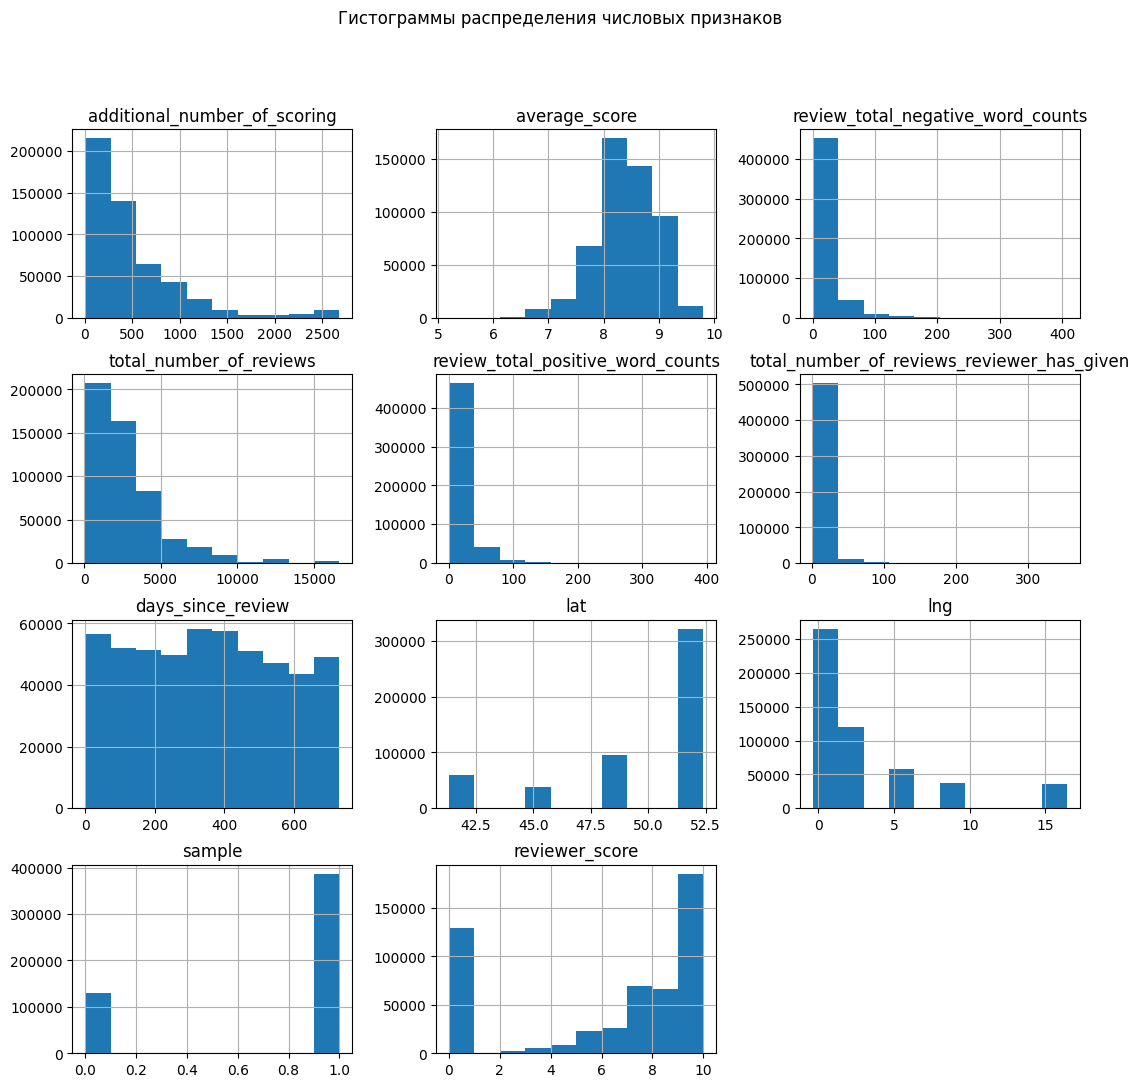

In [17]:
# Построим гистограммы распределения числовых признаков
fig, (ax1) = plt.subplots(1, figsize=(13, 12))
hotels.hist(ax=ax1)
plt.suptitle('Гистограммы распределения числовых признаков');

Признаки не распределены нормально. Необходимо использовать нормализацию.

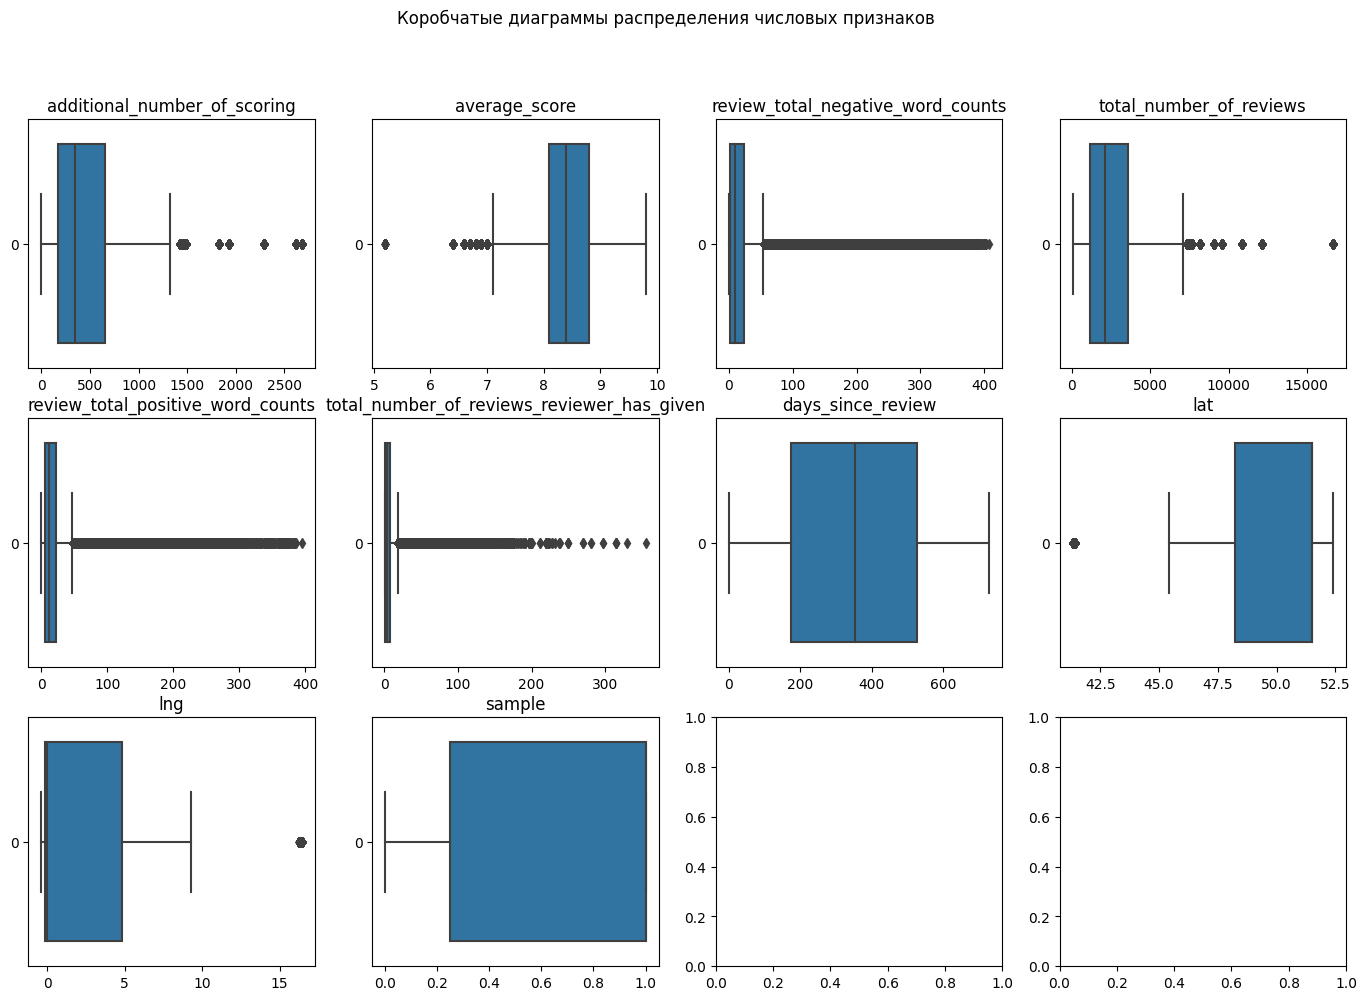

In [18]:
# Коробчатые диаграммы распределения числовых признаков
fig, axes = plt.subplots(3, 4, figsize=(17, 11))

cols = hotels.select_dtypes(include='number').columns
for i in range(10):
    sns.boxplot(hotels[cols[i]], ax=axes[i // 4][i % 4],
                orient='h')
    axes[i // 4][i % 4].set_title(cols[i])
    axes[i // 4][i % 4].set_xlabel('')
    
plt.suptitle('Коробчатые диаграммы распределения числовых признаков');

Из коробчатой диаграммы видно, что выбросы присутствуют во всех признаках, кроме day_since_review. 

Лучше использовать медиану.

In [19]:
# Получим статистические характеристики для количественных признаков
hotels.describe(include=['int64', 'float64'])

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,days_since_review,lat,lng,sample,reviewer_score
count,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000
mean,498.081836,8.397487,18.539450,2743.743944,17.776458,7.166001,354.441932,49.455489,2.805763,0.749999,6.297672
std,500.538467,0.548048,29.690831,2317.464868,21.804185,11.040228,208.928124,3.459188,4.570480,0.433014,3.902295
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.000000,0.000000,41.328376,-0.369758,0.000000,0.000000
25%,169.000000,8.100000,2.000000,1161.000000,5.000000,1.000000,175.000000,48.214662,-0.143372,0.250000,0.625000
50%,341.000000,8.400000,9.000000,2134.000000,11.000000,3.000000,353.000000,51.500732,-0.000250,1.000000,7.900000
75%,660.000000,8.800000,23.000000,3613.000000,22.000000,8.000000,527.000000,51.516288,4.831098,1.000000,9.600000
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.000000,730.000000,52.400181,16.429233,1.000000,10.000000


In [20]:
# Получим статистические характеристики для категориальных признаков
hotels.describe(include='object')

,hotel_address,review_date,hotel_name,reviewer_nationality,negative_review,positive_review,tags
count,515738,515738,515738,515738,515738,515738,515738
unique,1493,731,1492,227,330011,412601,55242
top,163 Marsh Wall Docklands Tower Hamlets London ...,8/2/2017,Britannia International Hotel Canary Wharf,United Kingdom,No Negative,No Positive,"[' Leisure trip ', ' Couple ', ' Double Room '..."
freq,4789,2585,4789,245246,127890,35946,5101


#### *Выводы по визуальному анализу*

Числовые признаки:

- additional_number_of_scoring находится в пределах от 1 до 2682 , среднее значение - 498, медиана - 341. Имеет смысл применить к нему нормализацию методом RobustScaler.

- average_score находится в пределах от 5.2 до 9.8, среднее значение и медиана оценки - 8.4. Данный признак гипотетически может внести большой вклад в предсказании рейтинга. Также можно применить нормализацию RobustScaler.

- review_total_negative_word_counts распределен в диапазоне от 0 до 408 слов, среднее значение - 18, медиана - 9 (нормализация RobustScaler). 
ВНИМАНИЕ! В этом поле также учитываются тексты из поля negative_review, которые не относятся к отрицательной оценке отеля, например: 
'no negative', 'nothing', 'nothing really', 'absolutely nothing', 'n a', 'na', 'none', 'no', 'nil', 'nothing at all', 'everything was perfect', 'everything was great', 'location is great', 'location is good', 'all good', 'no complaints', 'nothing to dislike'. 
Поскольку поле review_total_negative_word_counts оценивает "силу негатива", поэтому для таких значений поле review_total_negative_word_counts нужно обнулять.

- total_number_of_reviews имеет размах от 43 до 16670 отзывов, среднее - 2744, медиана - 2134 (нормализация RobustScaler). 

- review_total_positive_word_counts находится в пределах от 0 до 395 слов, среднее значение - 18, медиана - 11 (нормализация RobustScaler). 
ВНИМАНИЕ! В этом поле также учитываются тексты из поля positive_review, которые не относятся к положительной оценке отеля, например: 
'no positive', 'nothing', 'nothing really', 'absolutely nothing', 'n a', 'na', 'none', 'no', 'nil', 'nothing at all', 'nothing not to like'. 
Поскольку поле review_total_positive_word_counts оценивает "силу позитива", поэтому для таких значений поле review_total_positive_word_counts нужно обнулять.

- total_number_of_reviews_reviewer_has_given имеет размах от 1 до 355 отзывов, среднее - 7, медиана - 3 (нормализация RobustScaler). 

- days_since_review находится в пределах от 0 до 730, среднее значение 354, медиана - 353. В данном признаке отсутствуют выбросы, можно применить нормализацию MinMaxScaler.

- lat на графике представлен 4 одинокими пеньками (нормализация RobustScaler).

- lng по аналогии с lat также нормализуем методом RobustScaler.

- reviewer_score распределен в диапазоне от 0 до 10, средняя оценка - 6.2, медиана - 7.9. Данный признак является целевым для предсказания.

Категориальные признаки:

- hotel_address имеет 1493 уникальных адресов. Частота самого популярного значения - 4789. Имеет смысл извлечь из адреса страну отеля.

- review_date имеет слишком много для категорий уникальных значений 731. Можно выделить: ВРЕМЯ ГОДА, МЕСЯЦ, ДЕНЬ НЕДЕЛИ.

- hotel_name меет 1492 уникальных адресов. Видимо один из отелей имеет 2 адреса. Выделим ключевые слова в названии отелей и создадим по ним признаки.

- reviewer_nationality представлен 227 разными странами, но почти половина отзывов приходится на рецензентов из Великобритании. Посмотрим, влияет ли совпадении страны рецензента и страны отеля на оценку.

- negative_review и positive_review вносят самый большой вклад в оценку отеля. Проанализируем тональность отзывов и получим признаки с числовым выражением настроения. Необходимо учесть самые популярные сочетания слов - 'No Negative' и 'No Positive', которые носят положительные и отрицательные настроения соответственно.

- tags также имеет большое количество уникальных значений. Посчитаем количество тегов, извлечём из тегов информацию о количестве ночей, проведенных в отеле, а также вывведем информацию о наличии самого популярного тега.

### Создание новых признаков

In [21]:
# Функция визуализации графиков
def visualization(hotels, x, title, rotation):
    # Переименуем столбцы во избежании ошибки
    hotels.columns = [x, 'count_values', 'median_score']
    
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    hotels = hotels.sort_values('count_values', ascending=False)
    
    # Столбчатая диаграмма количества записей 
    sns.barplot(data=hotels, x=x, y='count_values', ax=axes[0])
    axes[0].set(ylabel='Количество')
    axes[0].set_title(title + 'по количеству записей')
    axes[0].tick_params(labelrotation=rotation, axis='x')
    
    hotels = hotels.sort_values('median_score', ascending=False)
    
    # Столбчатая диаграмма медианы рейтинга
    sns.barplot(data=hotels.sort_values('median_score', ascending=False),
                x=x, y='median_score', ax=axes[1])
    axes[1].set(ylabel='Средний рейтинг')
    axes[1].set_title(title + 'по медиане рейтинга отелей')
    axes[1].tick_params(labelrotation=rotation, axis='x')
    
    plt.show();

Создадим признак страны

In [22]:
hotels['hotel_country'] = hotels['hotel_address'].apply(
    lambda x: x.split(' ')[-1].replace('Kingdom', 'United Kingdom'))

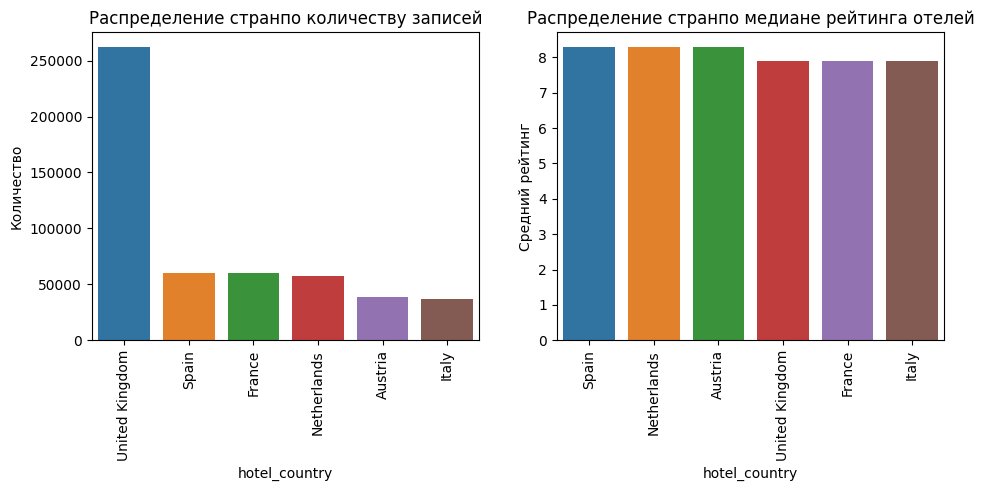

In [23]:
df = hotels.groupby('hotel_country')['reviewer_score'].agg(['count', 'median']).\
    reset_index('hotel_country')
visualization(df, 'hotel_country', 'Распределение стран', 90)

Из графиков видно, у стран есть небольшое отличие по медиане рейтинга, а половина отзывов приходится на отели из Великобритании.

Создадим признаки ВРЕМЯ ГОДА, МЕСЯЦ, ДЕНЬ НЕДЕЛИ отзыва

In [24]:
import datetime

# преобразуем review_date в тип DateTime
hotels['review_date_DT'] = pd.to_datetime(hotels['review_date'])

# 1. Извлечение месяца:
hotels['review_month'] = hotels['review_date_DT'].apply(lambda x: x.month)

# 2. Извлечение времени года: 1-ВЕСНА, 2-ЛЕТО, 3-ОСЕНЬ, 4-ЗИМА
def get_season(month):
    if 3 <= month <= 5:
        return 1
    elif 6 <= month <= 8:
        return 2
    elif 9 <= month <= 11:
        return 3
    else:
        return 4

hotels['review_season'] = hotels['review_month'].apply(lambda x: get_season(x))

# 3. Извлечение дня недели:
hotels['review_week'] = hotels['review_date_DT'].apply(lambda x: x.weekday()) # Понедельник - 0, Воскресенье - 6

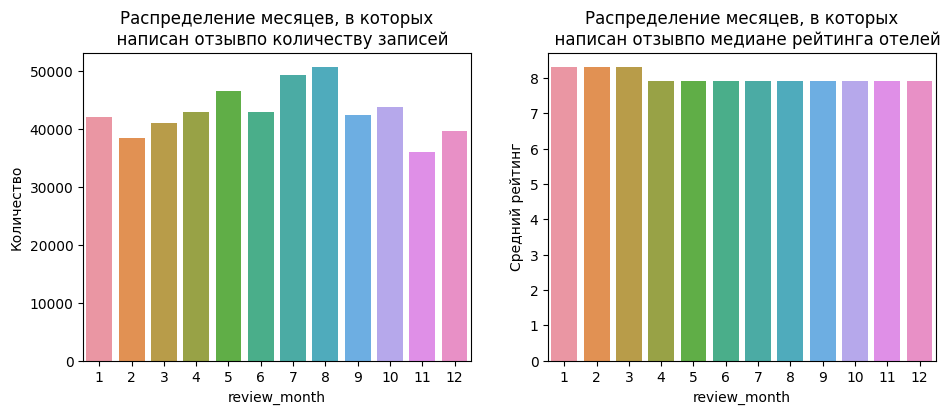

In [25]:
# Проанализируем 'review_month'
df = hotels.groupby('review_month')['reviewer_score'].agg(['count', 'median']).\
    reset_index('review_month')
visualization(df, 'review_month', 'Распределение месяцев, в которых\n  написан отзыв', 0)

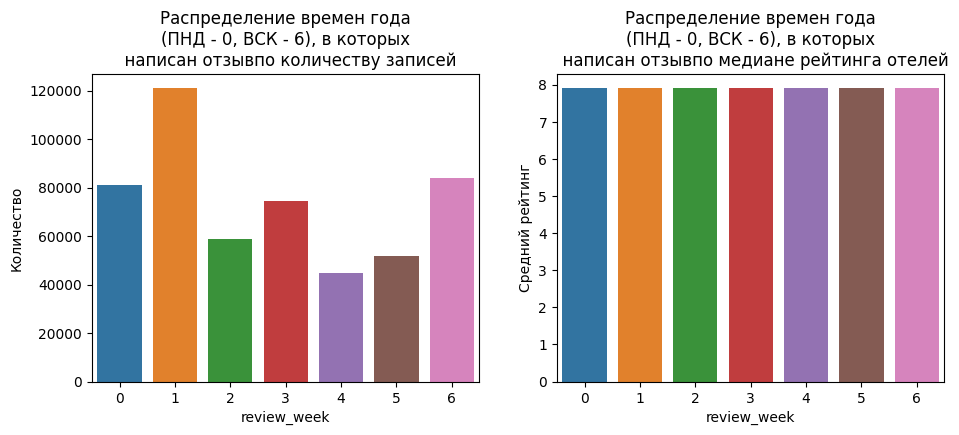

In [26]:
# Проанализируем 'review_week'
df = hotels.groupby('review_week')['reviewer_score'].agg(['count', 'median']).\
    reset_index('review_week')
visualization(df, 'review_week', 'Распределение времен года\n(ПНД - 0, ВСК - 6), в которых\n  написан отзыв', 0)

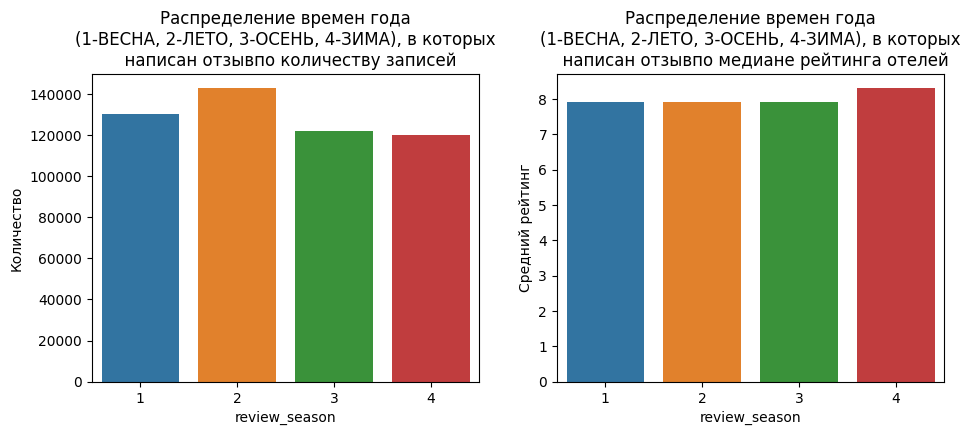

In [27]:
# Проанализируем 'review_season'
df = hotels.groupby('review_season')['reviewer_score'].agg(['count', 'median']).\
    reset_index('review_season')
visualization(df, 'review_season', 'Распределение времен года\n(1-ВЕСНА, 2-ЛЕТО, 3-ОСЕНЬ, 4-ЗИМА), в которых\n  написан отзыв', 0)

ВЫВОД: принципиальное отличие есть только в количестве отзывов по временам года, месяцам и дням недели. Средний рейтинг практически не зависит от этих признаков.

Создадим список наличия ключевых слов в названии отелей

In [28]:
words = {'Park', 'Plaza', 'Holiday', 'Hilton', 'Grand', 'Palace', 'Royale'}
hotels['name_with_keyword'] = hotels['hotel_name'].apply(
       lambda x: 1 if set(x.split(' ')).intersection(words)  else 0)

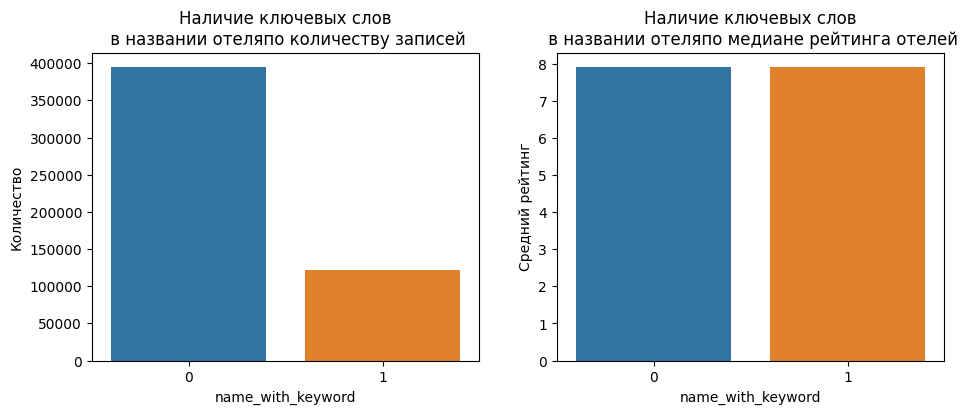

In [29]:
df = hotels.groupby('name_with_keyword')['reviewer_score'].agg(['count', 'median']).\
    reset_index('name_with_keyword')
df.columns = ['name_with_keyword', 'count_values', 'median_score']
visualization(df, 'name_with_keyword', 'Наличие ключевых слов\n в названии отеля', 0)

Судя по графикам, наличие ключевых слов в названии отеля не влияет на медиану оценки. 

При этом отелей с ключевыми словами существенно меньше, чем без них. Лучше сразу удалить данный признак.

In [30]:
hotels.drop('name_with_keyword', axis=1, inplace=True)

Создадим признак, показывающий, совпадает ли страна рецензента со страной отеля

In [31]:
hotels['is_country_reviewer'] = hotels.apply(
    lambda row: 1 if row['reviewer_nationality'].strip() == row['hotel_country'] else 0, axis=1) 

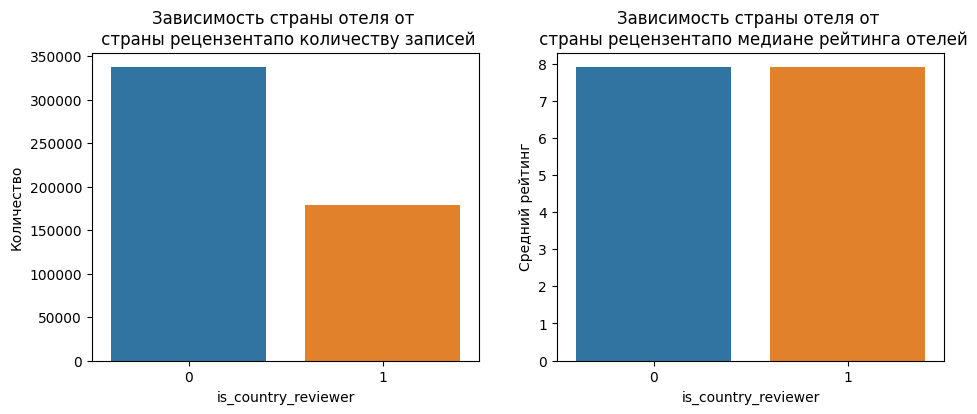

In [32]:
df = hotels.groupby('is_country_reviewer')['reviewer_score'].agg(['count', 'median']).\
    reset_index('is_country_reviewer')
visualization(df, 'is_country_reviewer', 'Зависимость страны отеля от \n страны рецензента', 0)

Исходя из визуального анализа можно сделать вывод, что рейтинг не зависит от совпадения страны рецензета и страны отеля. Удалим данный признак. 

In [33]:
hotels.drop('is_country_reviewer', axis=1, inplace=True)

Создадим признаки настроения - положительных и отрицательных отзывов

In [34]:
# Функция создания признаков для анализа настроений
# 'negative_review_neg' - негативное настроение в негативном отзыве
# 'negative_review_neu' - нейтральное настроение в негативном отзыве
# 'negative_review_pos' - позитивное настроение в негативном отзыве
# 'negative_review_compound' - смешанное настроение в негативном отзыве
# 'positive_review_neg' - негативное настроение в позитивном отзыве
# 'positive_review_neu' - нейтральное настроение в позитивном отзыве
# 'positive_review_pos' - позитивное настроение в позитивном отзыве
# 'positive_review_compound' - смешанное настроение в позитивном отзыве

def review_analyzer(feature_list):
    # Цикл по анализируемому списку признаков
    for feature in feature_list:
        hotel_review_list = hotels[feature].apply(
            lambda x: x.replace('No Positive', 'Negative').replace('No Negative', 'Positive'))
        
        # Создаем инструмент для анализа и словарь числовых значений
        sent_analyzer = SentimentIntensityAnalyzer()
        dict_analysis = defaultdict(list)

        # В цикле по строкам заполняем словарь
        for row in hotel_review_list:
            analysis_row = sent_analyzer.polarity_scores(row)
    
            for key in analysis_row:
                dict_analysis[key].append(analysis_row[key])
        
        # Создаём 4 признака настроений
        for key in dict_analysis:
            hotels[feature + '_' + key] = pd.Series(dict_analysis[key])
            
# Вызовем функцию анализа для признаков с отзывами           
review_analyzer(['negative_review', 'positive_review'])

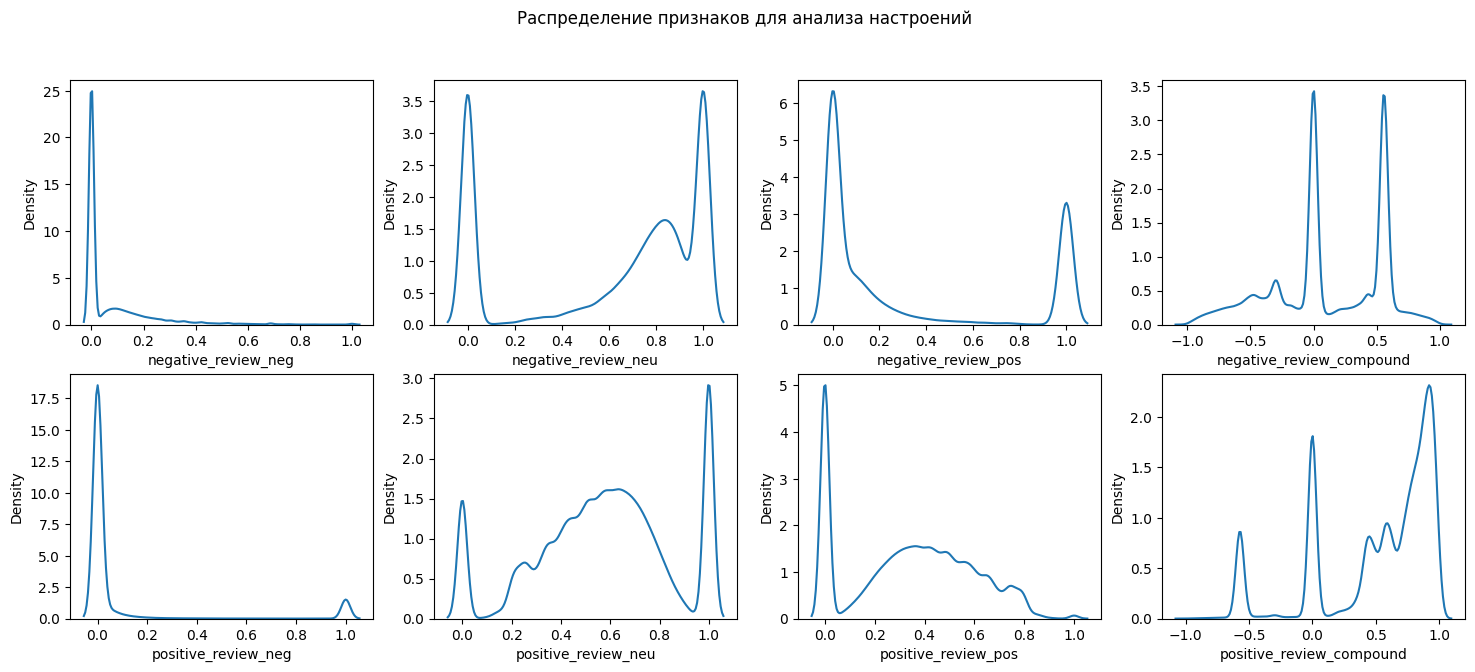

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))

cols = ['negative_review_neg', 'negative_review_neu',
        'negative_review_pos', 'negative_review_compound',
        'positive_review_neg', 'positive_review_neu', 
        'positive_review_pos', 'positive_review_compound']

for i in range(8):
    sns.kdeplot(hotels[cols[i]], ax=axes[i//4][i%4], label=cols[i])
    
plt.suptitle('Распределение признаков для анализа настроений');

Как можно судить по графикам, данные распределены ненормально. У большинства графиков пики распределения находятся в крайних значений - 0 и 1. Выделяются графики compound, там присутствуют пики около значений 0.5 и - 0.5.

Создадим признак количества тегов в отзыве

In [36]:
hotels['count_tags'] = hotels['tags'].apply(lambda x: len(x.split(',')))

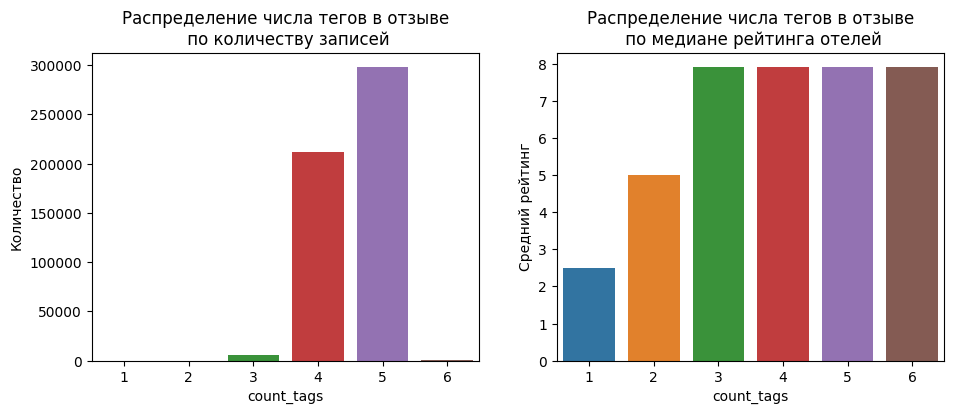

In [37]:
df = hotels.groupby('count_tags')['reviewer_score'].agg(['count', 'median']).\
    reset_index('count_tags')
visualization(df, 'count_tags', 'Распределение числа тегов в отзыве\n ', 0)

Как видно из графиков рейтинг растёт с увеличением числа тегов, но после трех тегов перестаёт расти. Максимальное количество записей у отзывов с 5 тегами.

Создадим признак наличия самого популярного тега

In [38]:
tags_string =', '.join(list(hotels['tags']))
tags_string = tags_string.replace('[', '').replace(']', '').replace('\'', '')
tags_list = tags_string.split(', ')
tag = pd.Series(tags_list).mode()[0]

hotels['tag_mode'] = hotels['tags'].apply(
    lambda x: 1 if x.find(tag.strip()) >= 0 else 0)

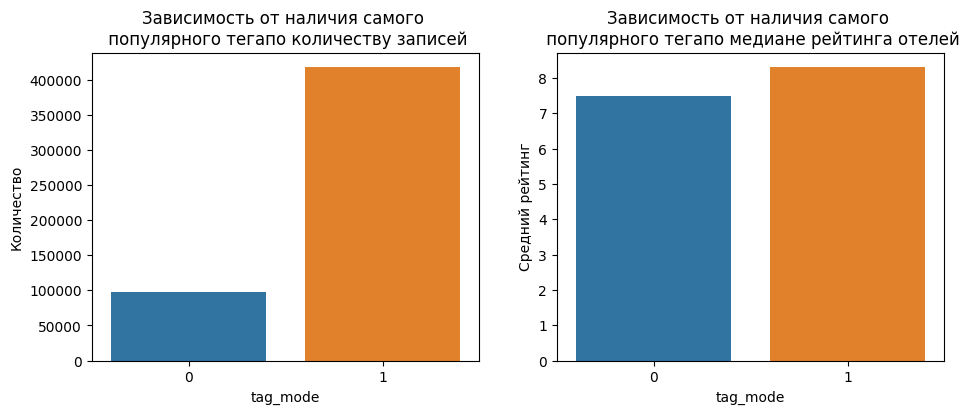

In [39]:
df = hotels.groupby('tag_mode')['reviewer_score'].agg(['count', 'median']).\
    reset_index('tag_mode')
visualization(df, 'tag_mode', 'Зависимость от наличия самого \n популярного тега', 0)

Можно сказать, что наличие ключевого тега положительно сказывается на оценке отеля. С другой стороны данный тег содержится в большинстве отзывов.

Создадим признак количества ночей, проведенных в отеле

In [40]:
hotels['count_nights'] = hotels['tags'].str.findall('(\d*)\snight').str.get(0)
# пропущенные значения заменим на 1
hotels['count_nights'] = hotels['count_nights'].replace('', 1).replace(np.NaN, 1)
hotels['count_nights'] = hotels['count_nights'].astype('int64')

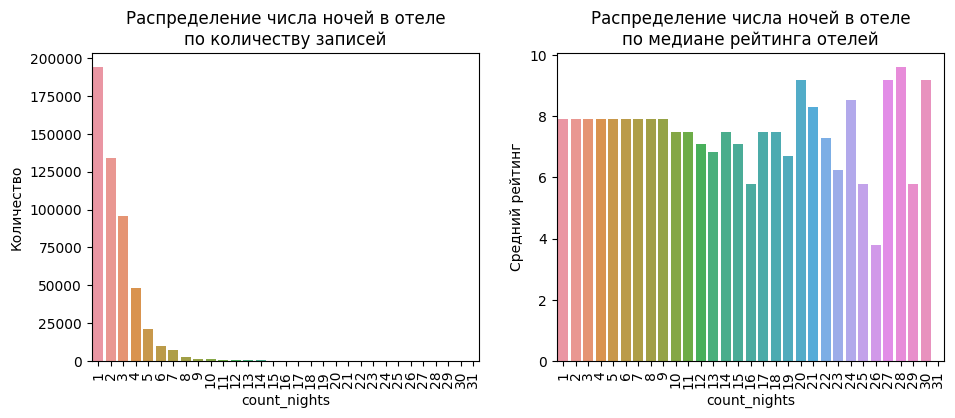

In [41]:
df = hotels.groupby('count_nights')['reviewer_score'].agg(['count', 'median']).\
    reset_index('count_nights')
visualization(df, 'count_nights', 'Распределение числа ночей в отеле\n', 90)

С увеличением числа ночей, проведенных в отделе, уменьшается количества соответсвтвующих записией. Также видно, что после 9 ночей медиана рейтинга начинается отличаться.

### Преобразование признаков

#### Кодирование признаков

In [42]:
# Закодируем признак страны отеля 
categorical_columns_names = ['hotel_country']
hotels = pd.get_dummies(hotels, columns = categorical_columns_names, dtype=int)

#### Нормализация признаков

In [43]:
# Нормализуем признаки с выбросами при помощи RobustScaler
r_scaler = preprocessing.RobustScaler()
r_columns = ['lat', 'lng', 'additional_number_of_scoring', 'average_score',
             'review_total_negative_word_counts', 'total_number_of_reviews',
             'review_total_positive_word_counts',
             'total_number_of_reviews_reviewer_has_given',
             'count_tags', 'count_nights'
            ]

df_r = r_scaler.fit_transform(hotels[r_columns])
df_r = pd.DataFrame(df_r, columns=r_columns)

hotels = pd.concat([hotels, df_r], axis=1)

# Нормализуем признак без выбросов при помощи MinMaxScaler
mm_scaler = preprocessing.MinMaxScaler()
mm_columns = ['days_since_review', 'hotel_country_Austria',
              'hotel_country_France', 'hotel_country_Italy',
              'hotel_country_Netherlands', 'hotel_country_Spain',
              'hotel_country_United Kingdom',
              'negative_review_neg', 'negative_review_neu', 'negative_review_pos', 'negative_review_compound',
              'positive_review_neg', 'positive_review_neu', 'positive_review_pos', 'positive_review_compound',
              'review_month', 'review_season', 'review_week'
             ]

df_mm = mm_scaler.fit_transform(hotels[mm_columns])
df_mm = pd.DataFrame(df_mm, columns=mm_columns)

hotels = pd.concat([hotels, df_mm], axis=1)

Удалим лишние признаки

In [44]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   hotel_address                               515738 non-null  object        
 1   additional_number_of_scoring                515738 non-null  int64         
 2   review_date                                 515738 non-null  object        
 3   average_score                               515738 non-null  float64       
 4   hotel_name                                  515738 non-null  object        
 5   reviewer_nationality                        515738 non-null  object        
 6   negative_review                             515738 non-null  object        
 7   review_total_negative_word_counts           515738 non-null  int64         
 8   total_number_of_reviews                     515738 non-null  int64        

In [45]:
object_columns = hotels.select_dtypes('object').columns
hotels.drop(object_columns, axis = 1, inplace=True)
object_columns = hotels.select_dtypes('datetime64').columns
hotels.drop(object_columns, axis = 1, inplace=True)

In [46]:
hotels.columns

Index(['additional_number_of_scoring', 'average_score',
       'review_total_negative_word_counts', 'total_number_of_reviews',
       'review_total_positive_word_counts',
       'total_number_of_reviews_reviewer_has_given', 'days_since_review',
       'lat', 'lng', 'sample', 'reviewer_score', 'review_month',
       'review_season', 'review_week', 'negative_review_neg',
       'negative_review_neu', 'negative_review_pos',
       'negative_review_compound', 'positive_review_neg',
       'positive_review_neu', 'positive_review_pos',
       'positive_review_compound', 'count_tags', 'tag_mode', 'count_nights',
       'hotel_country_Austria', 'hotel_country_France', 'hotel_country_Italy',
       'hotel_country_Netherlands', 'hotel_country_Spain',
       'hotel_country_United Kingdom', 'lat', 'lng',
       'additional_number_of_scoring', 'average_score',
       'review_total_negative_word_counts', 'total_number_of_reviews',
       'review_total_positive_word_counts',
       'total_number_of_r

In [47]:
# Удалить первое вхождение каждого дублирующегося имени столбца
duplicates = hotels.columns[hotels.columns.duplicated()].tolist()
hotels = hotels.loc[:,~hotels.columns.duplicated()]

In [48]:
hotels.columns

Index(['additional_number_of_scoring', 'average_score',
       'review_total_negative_word_counts', 'total_number_of_reviews',
       'review_total_positive_word_counts',
       'total_number_of_reviews_reviewer_has_given', 'days_since_review',
       'lat', 'lng', 'sample', 'reviewer_score', 'review_month',
       'review_season', 'review_week', 'negative_review_neg',
       'negative_review_neu', 'negative_review_pos',
       'negative_review_compound', 'positive_review_neg',
       'positive_review_neu', 'positive_review_pos',
       'positive_review_compound', 'count_tags', 'tag_mode', 'count_nights',
       'hotel_country_Austria', 'hotel_country_France', 'hotel_country_Italy',
       'hotel_country_Netherlands', 'hotel_country_Spain',
       'hotel_country_United Kingdom'],
      dtype='object')

### Отбор признаков

#### Корреляционный анализ

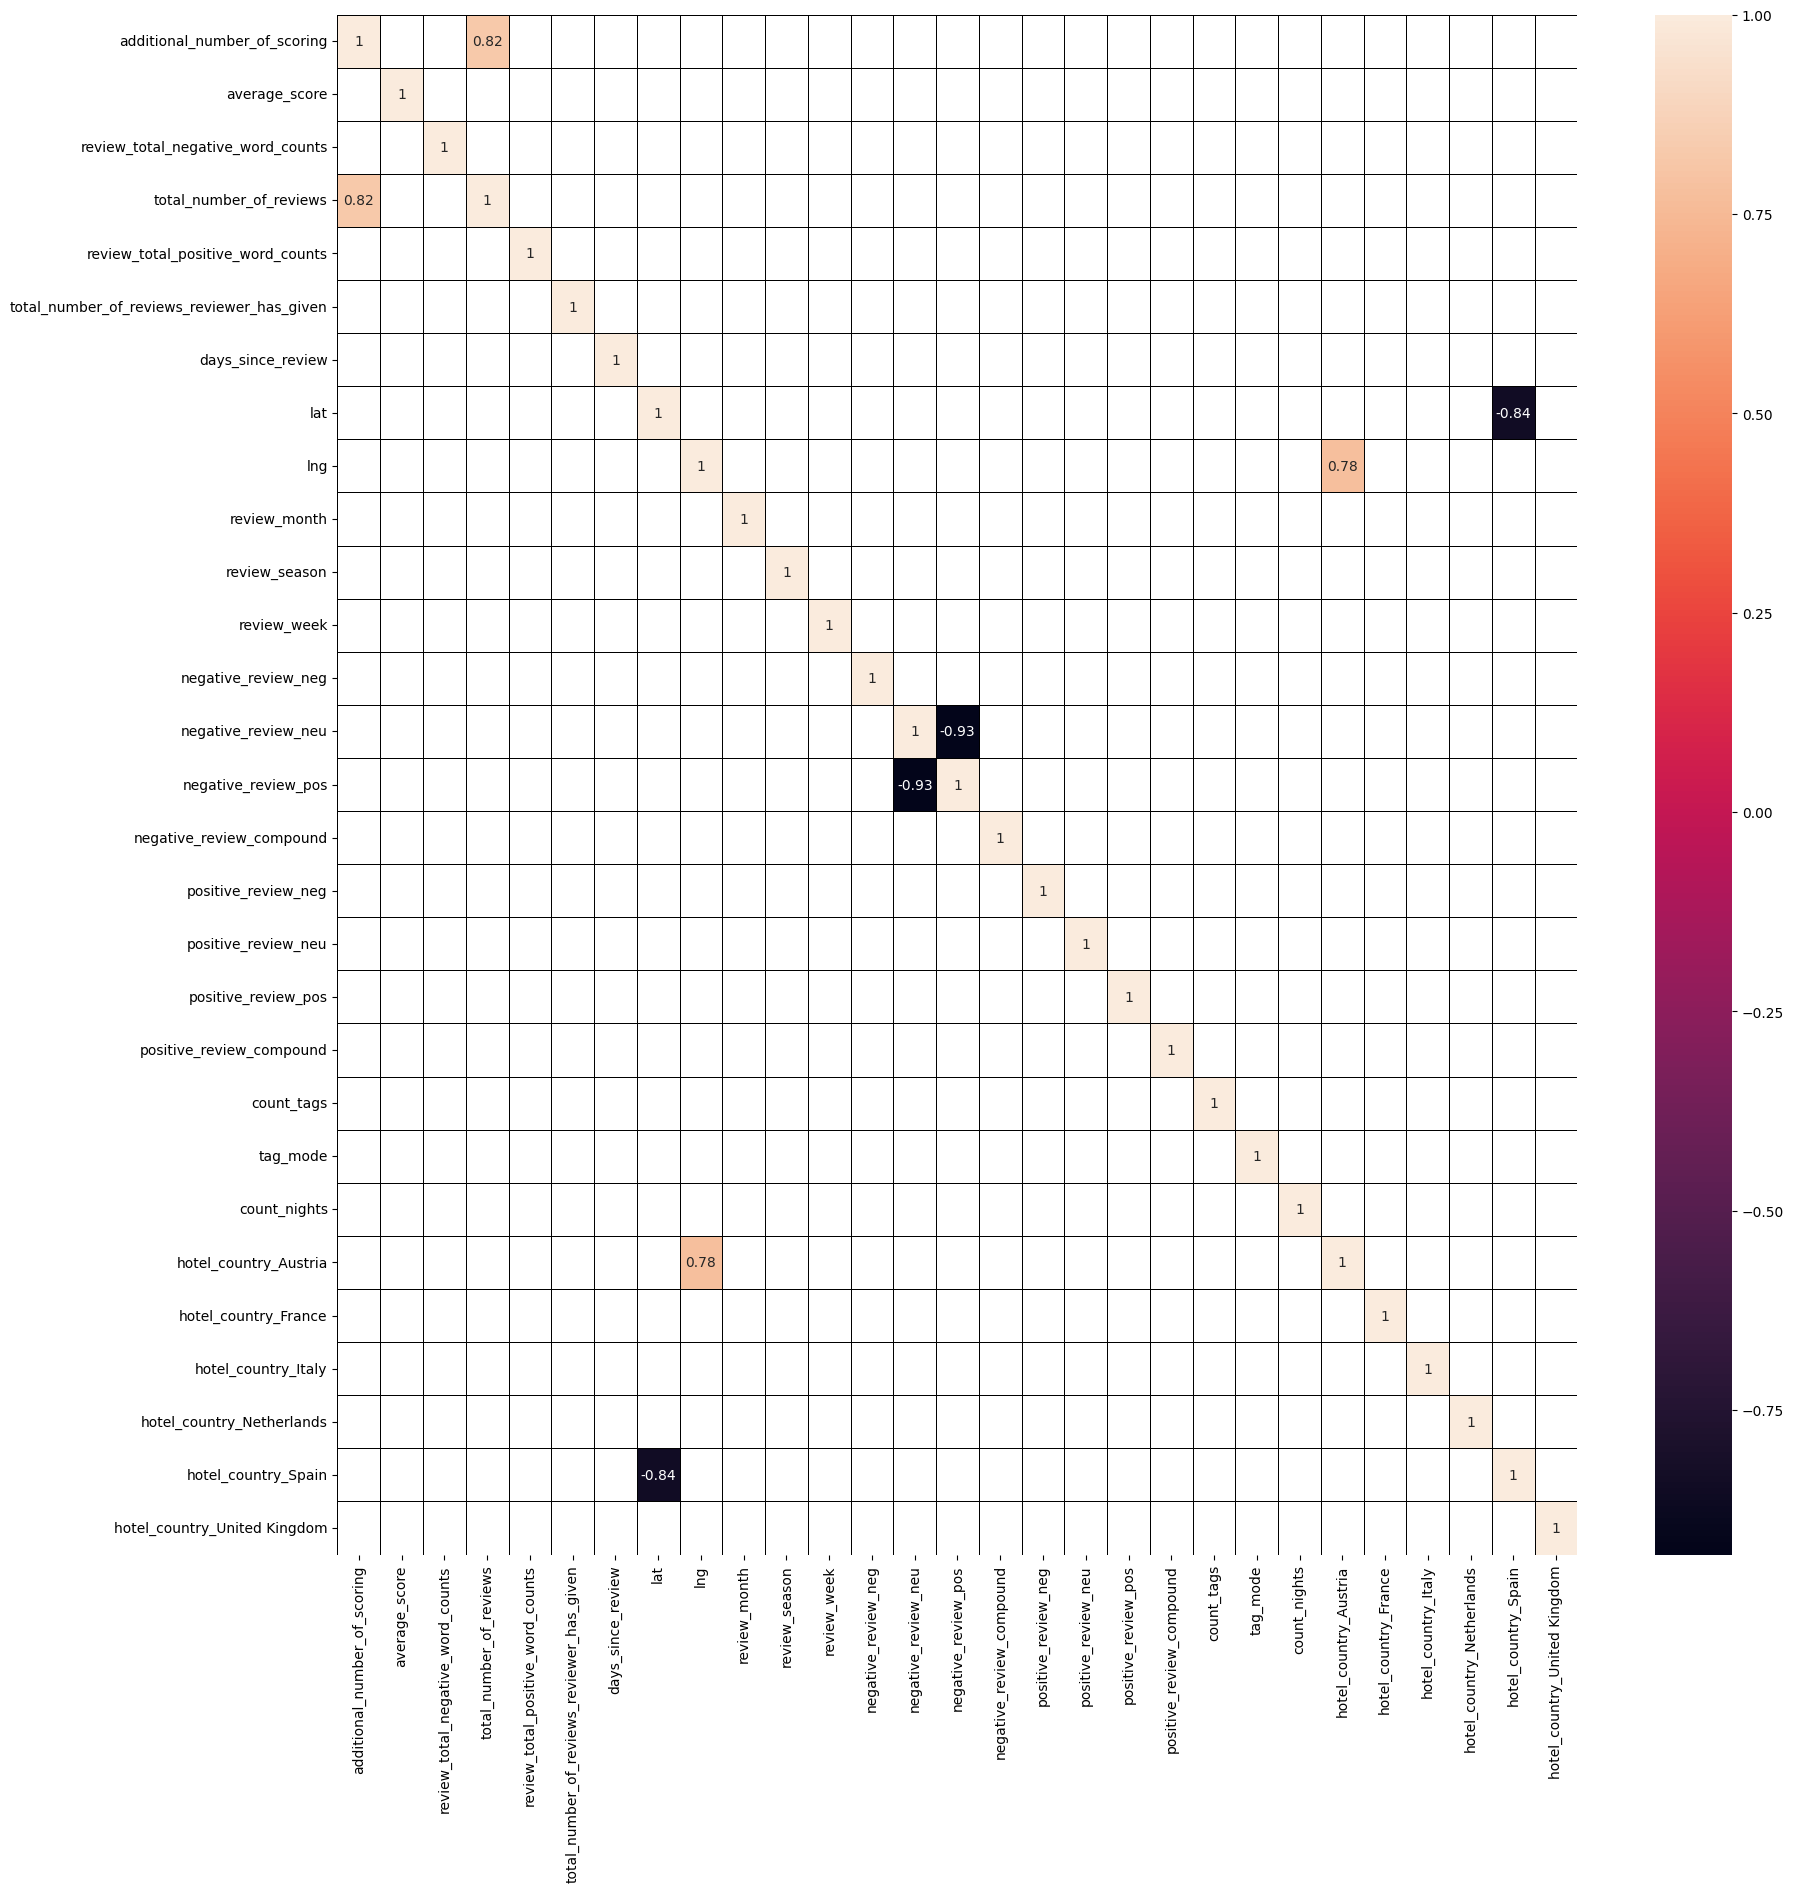

In [49]:
# Тепловая карта признаков с сильной корреляцией
hotels_corr = hotels.drop(['sample', 'reviewer_score'], axis=1)

fig, (ax1) = plt.subplots(ncols=1, figsize=(20, 20))
corr = hotels_corr.corr()
corr_strong = corr[abs(corr) >= 0.7]
sns.heatmap(corr_strong,  linewidths=0.5, linecolor='black', annot=True);

Корреляционный анализ показал наличие признаков с сильной корреляцией:

- total_number_of_reviews и additional_number_of_scoring
- negative_review_pos и negative_review_neu
- lng и hotel_country_Austria
- lat и hotel_country_Spain

Оценим значимость каждого признака и оставим самые информативные

#### Оценка значимости каждого признака в определении рейтинга отеля

In [50]:
# Возьмём абсолютное значение широты и долготы
hotels['lat'] = abs(hotels['lat'])
hotels['lng'] = abs(hotels['lng'])

# Непрерывные признаки
num_cols = ['lat', 'lng',
            'additional_number_of_scoring', 'average_score',
            'review_total_negative_word_counts', 'total_number_of_reviews',
            'review_total_positive_word_counts',
            'total_number_of_reviews_reviewer_has_given', 'count_tags',
            'count_nights', 'days_since_review',
            'negative_review_neg', 'negative_review_neu', 'negative_review_pos', 'negative_review_compound',
            'positive_review_neg', 'positive_review_neu', 'positive_review_pos', 'positive_review_compound'
           ]

# Категориальные признаки
cat_cols = ['tag_mode', 'review_month', 'review_season', 'review_week', 
            'hotel_country_Austria', 'hotel_country_France', 'hotel_country_Italy',
            'hotel_country_Netherlands', 'hotel_country_Spain', 'hotel_country_United Kingdom' 
           ]

In [51]:
# Теперь выделим тестовую часть
train_data = hotels.query('sample == 1').drop(['sample'], axis=1)
test_data = hotels.query('sample == 0').drop(['sample'], axis=1)

y = train_data.reviewer_score.values            # наш таргет
X = train_data.drop(['reviewer_score'], axis=1)

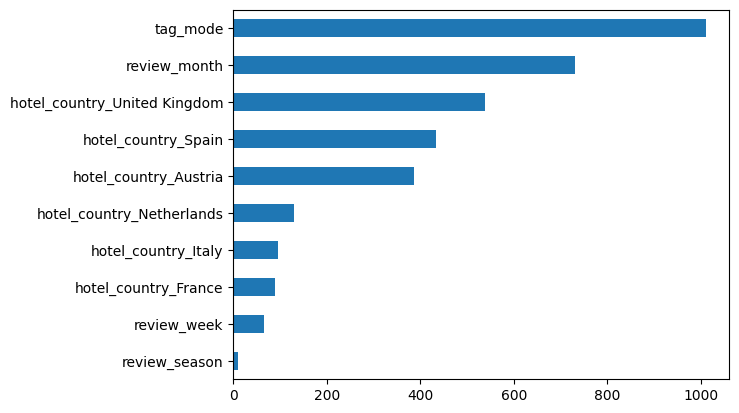

In [52]:
# Для оценки значимости категориальных переменных используем тест хи-квадрат
score = y.astype('int')

from sklearn.feature_selection import chi2

imp_cat = pd.Series(chi2(X[cat_cols], score)[0], index=cat_cols)
imp_cat.sort_values(inplace=True)
imp_cat.plot(kind='barh');

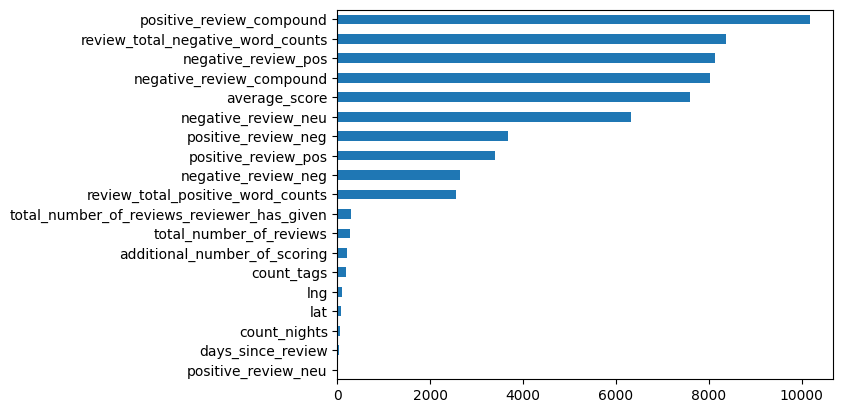

In [53]:
# Для оценки непрерывных переменных используем анализ ANOVA
from sklearn.feature_selection import f_classif

imp_num = pd.Series(f_classif(X[num_cols], score)[0], index=num_cols)
imp_num.sort_values(inplace=True)
imp_num.plot(kind='barh');

На основании корреляционного анализа и оценки значимости удалим менее значимые признаки.

In [54]:
cols= ['negative_review_neu', 'positive_review_neu',
       'lat', 'lng', 'additional_number_of_scoring',
       'review_season', 'count_nights', 'days_since_review']

train_data = train_data.drop(cols, axis=1)
test_data = test_data.drop(cols, axis=1)

X = X.drop(cols, axis=1)

In [55]:
# Воспользуемся специальной функцие train_test_split для разбивки тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [56]:
# проверяем
test_data.shape, train_data.shape, X.shape, X_train.shape, X_test.shape

((128935, 22), (386803, 22), (386803, 21), (309442, 21), (77361, 21))

In [57]:
# Создаём модель (НАСТРОЙКИ НЕ ТРОГАЕМ)
model = RandomForestRegressor(n_estimators=100, verbose=1, n_jobs=-1, random_state=RANDOM_SEED)

In [58]:
# Обучаем модель на тестовом наборе данных
model.fit(X_train, y_train)

# Используем обученную модель для предсказания рейтинга ресторанов в тестовой выборке.
# Предсказанные значения записываем в переменную y_pred
y_pred = model.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   51.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.9min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.7s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.6s finished


In [59]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они отличаются  
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений от фактических.  

# Функция для вычисления MAPE
def mape_func(Y_actual,Y_Predicted):
    mape = np.mean(np.abs((Y_actual - Y_Predicted)/Y_actual))*100
    return mape

print('MAPE:', mape_func(y_test, y_pred))

MAPE: 12.569881940286503


<Axes: >

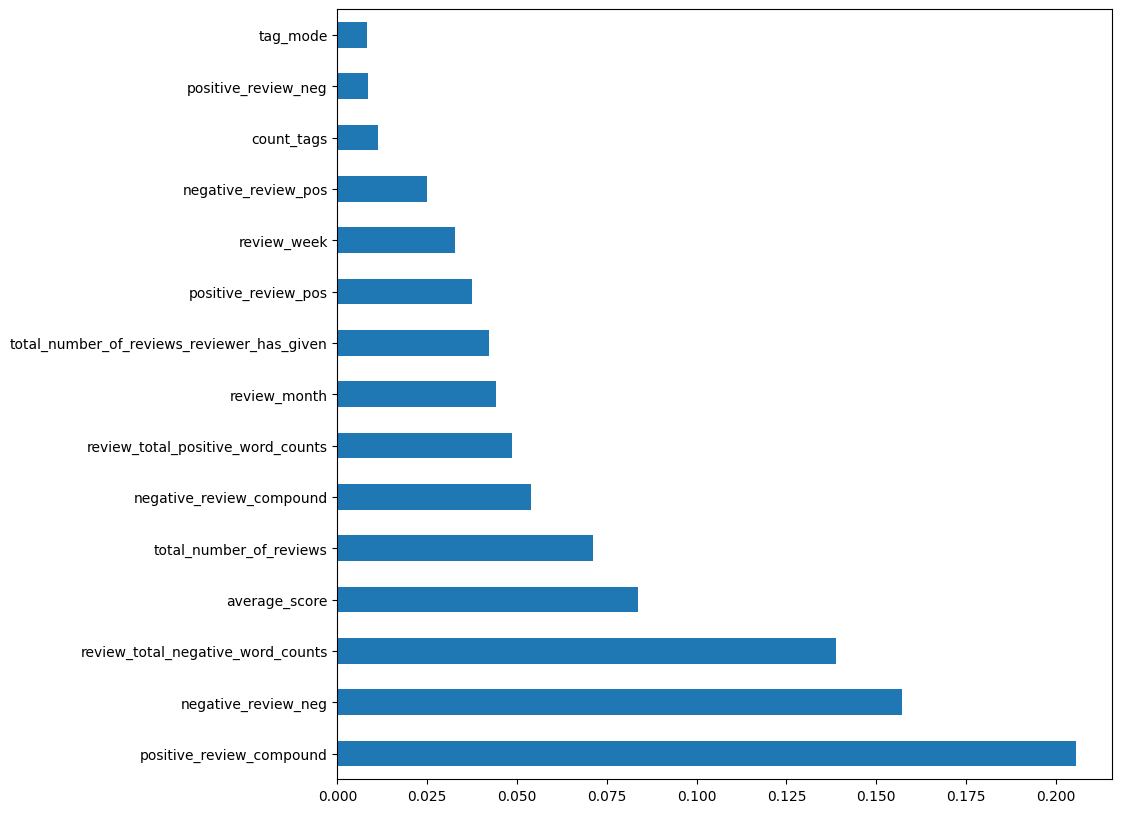

In [60]:
# в RandomForestRegressor есть возможность вывести самые важные признаки для модели
plt.rcParams['figure.figsize'] = (10,10)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')

In [61]:
test_data.sample(10)

,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,review_month,review_week,negative_review_neg,negative_review_pos,...,positive_review_pos,positive_review_compound,count_tags,tag_mode,hotel_country_Austria,hotel_country_France,hotel_country_Italy,hotel_country_Netherlands,hotel_country_Spain,hotel_country_United Kingdom
91389,8.4,115,4410,43,4,0.0,4,5,0.000,0.157,...,0.208,0.8750,5,1,0,0,0,1,0,0
122126,7.8,8,5726,8,1,0.0,9,0,0.217,0.311,...,0.359,0.4215,5,1,0,0,0,0,0,1
24083,8.8,106,1519,104,13,0.0,8,4,0.039,0.274,...,0.343,0.9914,4,1,0,0,0,0,0,1
38397,8.8,11,1072,31,3,0.0,7,6,0.000,0.000,...,0.443,0.9486,5,1,0,0,0,0,1,0
97050,9.0,13,2298,11,7,0.0,1,6,0.000,0.000,...,0.573,0.8555,5,1,0,0,0,0,0,1
21701,8.6,0,937,15,6,0.0,9,3,0.000,1.000,...,0.345,0.7003,4,1,0,1,0,0,0,0
124599,8.8,0,1420,39,2,0.0,12,6,0.000,1.000,...,0.325,0.9375,4,0,0,0,0,1,0,0
55168,9.4,53,2200,33,1,0.0,4,2,0.000,0.076,...,0.186,0.7506,5,1,0,0,0,0,0,1
61235,7.9,10,3944,0,1,0.0,11,0,0.217,0.294,...,0.000,-0.5719,4,0,0,0,0,0,1,0
105755,8.7,17,7491,14,5,0.0,11,6,0.156,0.000,...,0.490,0.8625,5,1,0,0,0,0,0,1


In [62]:
test_data = test_data.drop(['reviewer_score'], axis=1)

In [63]:
sample_submission = hotels_submission
sample_submission

,reviewer_score,id
0,1,488440
1,10,274649
2,3,374688
3,10,404352
4,9,451596
...,...,...
128930,7,495812
128931,1,315577
128932,3,511968
128933,6,303386


In [64]:
predict_submission = model.predict(test_data)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    1.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    2.6s finished


In [65]:
predict_submission

array([8.558, 7.888, 8.863, ..., 8.397, 9.502, 6.54 ])

In [66]:
list(sample_submission)

['reviewer_score', 'id']

In [67]:
sample_submission['reviewer_score'] = predict_submission
sample_submission.to_csv('submission.csv', index=False)
sample_submission.head(10)

,reviewer_score,id
0,8.558,488440
1,7.888,274649
2,8.863,374688
3,9.776,404352
4,9.493,451596
5,9.160,302161
6,7.416,317079
7,7.389,13963
8,8.431,159785
9,7.424,195089
